In [37]:
import polars as pl
from pathlib import Path
from plotnine import (
    ggplot, aes, geom_line, labs, theme_light,
    geom_vline, geom_hline, annotate, scale_color_manual, ggsave
)

In [10]:
def dh_state_expr():
    
    return (
        pl.when(pl.col("yearID") < 1973)
        .then(pl.lit("No DH (both)"))
        .when((pl.col("yearID").is_between(1973, 2019)) & (pl.col("lgID") == "AL"))
        .then(pl.lit("DH in AL; NL no DH"))
        .when((pl.col("yearID").is_between(1973, 2019)) & (pl.col("lgID") == "NL"))
        .then(pl.lit("NL no DH"))
        .when(pl.col("yearID") == 2020)
        .then(pl.lit("Universal DH (2020)"))
        .when((pl.col("yearID") == 2021) & (pl.col("lgID") == "AL"))
        .then(pl.lit("DH in AL; NL no DH"))
        .when((pl.col("yearID") == 2021) & (pl.col("lgID") == "NL"))
        .then(pl.lit("NL no DH"))
        .when(pl.col("yearID") >= 2022)
        .then(pl.lit("Universal DH (2022+)"))
        .otherwise(pl.lit("Unknown"))
        .alias("DH_state")
    )

In [11]:
# --- Task 1: ERA Analysis ---
pitching_url = 'https://github.com/akmtamimahmed/Lab-1.2/raw/main/data/lahman_1871-2024_csv/lahman_1871-2024_csv/Pitching.csv'
pitch_df = pl.read_csv(pitching_url)
pitch_modern = pitch_df.filter(pl.col("yearID") >= 1946)

era_group = (
    pitch_modern
    .group_by(["yearID", "lgID"])
    .agg([
        pl.col("ER").sum().alias("total_ER"),
        pl.col("IPouts").sum().alias("total_IPouts"),
    ])
    .with_columns(
        (pl.col("total_ER") / pl.col("total_IPouts") * 27).alias("ERA")
    )
     .select(["yearID", "lgID", "ERA"])
    .sort("yearID")
)
era_group.head()

yearID,lgID,ERA
i64,str,f64
1946,"""AL""",3.503345
1946,"""NL""",3.41174
1947,"""NL""",4.066987
1947,"""AL""",3.705309
1948,"""NL""",3.954666


In [12]:
# --- Task 2: Slugging Percentage Analysis ---
batting_url = 'https://github.com/akmtamimahmed/Lab-1.2/raw/main/data/lahman_1871-2024_csv/lahman_1871-2024_csv/Batting.csv'
bat_df = pl.read_csv(batting_url)
bat_modern = bat_df.filter(pl.col("yearID") >= 1946)

bat_group = (
    bat_modern
    .group_by(["yearID", "lgID"])
    .agg([
        pl.col("AB").sum().alias("total_AB"),
        pl.col("H").sum().alias("total_H"),
        pl.col("2B").sum().alias("total_2B"),
        pl.col("3B").sum().alias("total_3B"),
        pl.col("HR").sum().alias("total_HR"),
    ])
    .with_columns(
        (pl.col("total_H") + pl.col("total_2B") + 2 * pl.col("total_3B") + 3 * pl.col("total_HR")).alias("total_TB")
    )
    .with_columns(
        (pl.col("total_TB") / pl.col("total_AB")).alias("SLG")
    )
)
bat_group.head()

yearID,lgID,total_AB,total_H,total_2B,total_3B,total_HR,total_TB,SLG
i64,str,i64,i64,i64,i64,i64,i64,f64
2022,"""NL""",81649,19836,3984,348,2658,32490,0.397923
1951,"""NL""",42704,11088,1746,367,1024,16640,0.389659
1975,"""AL""",65371,16861,2662,429,1465,24776,0.379006
1981,"""NL""",43654,11141,1881,354,719,15887,0.36393
2002,"""NL""",87794,22753,4482,488,2595,35996,0.410005


In [13]:
pl.read_csv("league_era_by_year.csv").head()

yearID,lgID,total_ER,total_IPouts,ERA,DH_state
i64,str,i64,i64,f64,str
1965,"""AL""",5587,43618,3.458412,"""No DH (both)"""
2005,"""NL""",10833,69157,4.229377,"""NL no DH"""
2014,"""NL""",8878,65445,3.662709,"""NL no DH"""
1956,"""AL""",5098,33095,4.159118,"""No DH (both)"""
1996,"""AL""",11260,60815,4.999096,"""DH in AL; NL no DH"""


In [14]:
pl.read_csv("league_slugging_by_year.csv").head() 

yearID,lgID,total_AB,total_H,total_2B,total_3B,total_HR,total_TB,SLG,DH_state
i64,str,i64,i64,i64,i64,i64,i64,f64,str
2020,"""NL""",29399,7245,1402,126,1161,12382,0.421171,"""Universal DH (2020)"""
1997,"""NL""",77203,20300,3907,485,2163,31666,0.410165,"""NL no DH"""
2011,"""NL""",88119,22263,4394,487,2281,34474,0.391221,"""NL no DH"""
1964,"""NL""",55284,14032,2161,427,1211,20680,0.374068,"""No DH (both)"""
1965,"""NL""",55377,13794,2122,422,1318,20714,0.374054,"""No DH (both)"""


In [16]:
# --- 2. Wrangle Data for Plotting ---
# To plot the AL-NL difference, we first need to pivot the data to be "wide",
# with columns for AL and NL ERA for each year.
era_wide = era_group.pivot(
    index="yearID",
    on="lgID",
    values="ERA"
)

In [21]:
# Now, calculate the difference and then "melt" the DataFrame back to a "long"
# format, which is what plotnine prefers.
era_plot_df = (
    era_wide
    .with_columns(
        (pl.col("AL") - pl.col("NL")).alias("AL - NL")
    )
    .unpivot(index="yearID", variable_name="League", value_name="ERA")
)

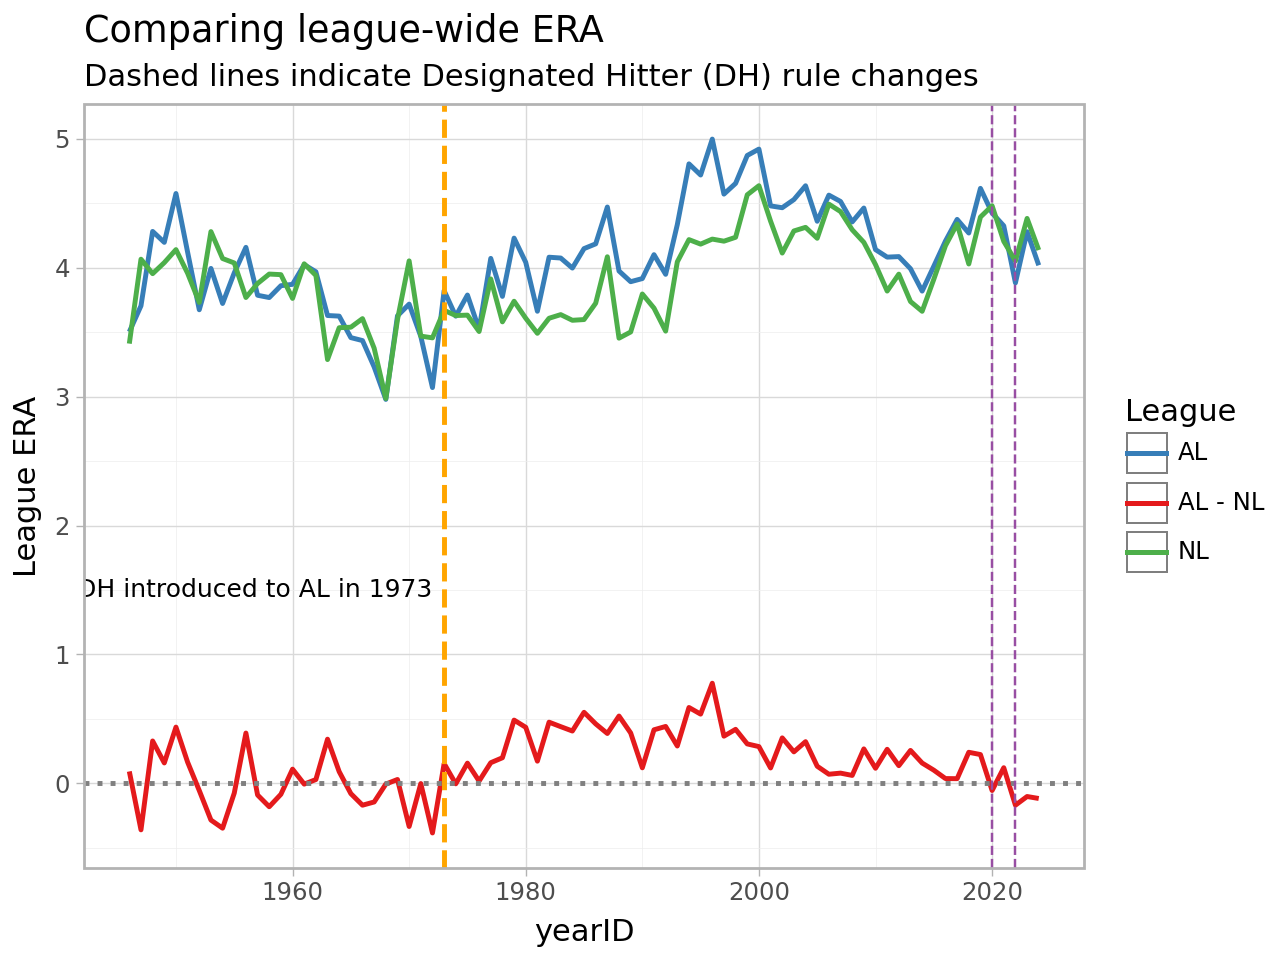

In [35]:
# --- 3. Create the Visualization with plotnine ---
# Define colors to match the example plot
league_colors = {"AL": "#377eb8", "NL": "#4daf4a", "AL - NL": "#e41a1c"} # Blue, Green, Red

era_plot = (
    ggplot(era_plot_df, aes(x="yearID", y="ERA", color="League"))
    + geom_line(size=1)
    # Add horizontal reference line at y=0 for the difference
    + geom_hline(yintercept=0, linetype="dotted", color="gray", size=1)
    # Add vertical lines for DH rule changes, per the instructions
    + geom_vline(xintercept=1973, linetype="dashed", color="orange", size=1)
    + geom_vline(xintercept=2020, linetype="dashed", color="#984ea3") # Purple
    + geom_vline(xintercept=2022, linetype="dashed", color="#984ea3")
    # Add annotations for the DH rule changes
    + annotate("text", x=1972, y=1.5, label="DH introduced to AL in 1973", ha="right", size=9)
    # Set labels, title, and subtitle
    + labs(
        title="Comparing league-wide ERA",
        subtitle="Dashed lines indicate Designated Hitter (DH) rule changes",
        x="yearID",
        y="League ERA",
        color="League"
    )
    # Manually set the line colors
    + scale_color_manual(values=league_colors)
    # Use a clean theme
    + theme_light()
)
era_plot

In [26]:
# Load and Prepare Slugging Data
batting_url = 'https://github.com/akmtamimahmed/Lab-1.2/raw/main/data/lahman_1871-2024_csv/lahman_1871-2024_csv/Batting.csv'
bat_df = pl.read_csv(batting_url)
slg_group = (
    bat_df
    .filter((pl.col("yearID") >= 1946) & (pl.col("lgID").is_in(["AL", "NL"])))
    .group_by(["yearID", "lgID"])
    .agg(
        ((pl.col("H") + pl.col("2B") + 2 * pl.col("3B") + 3 * pl.col("HR")).sum() / pl.col("AB").sum()).alias("stat")
    )
    .sort("yearID")
)

In [27]:
# Wrangle Slugging Data for Plotting
slg_wide = slg_group.pivot(index="yearID", on="lgID", values="stat")
slg_plot_df = (
    slg_wide
    .with_columns((pl.col("AL") - pl.col("NL")).alias("AL - NL"))
    .unpivot(index="yearID", variable_name="League", value_name="SLG")
)

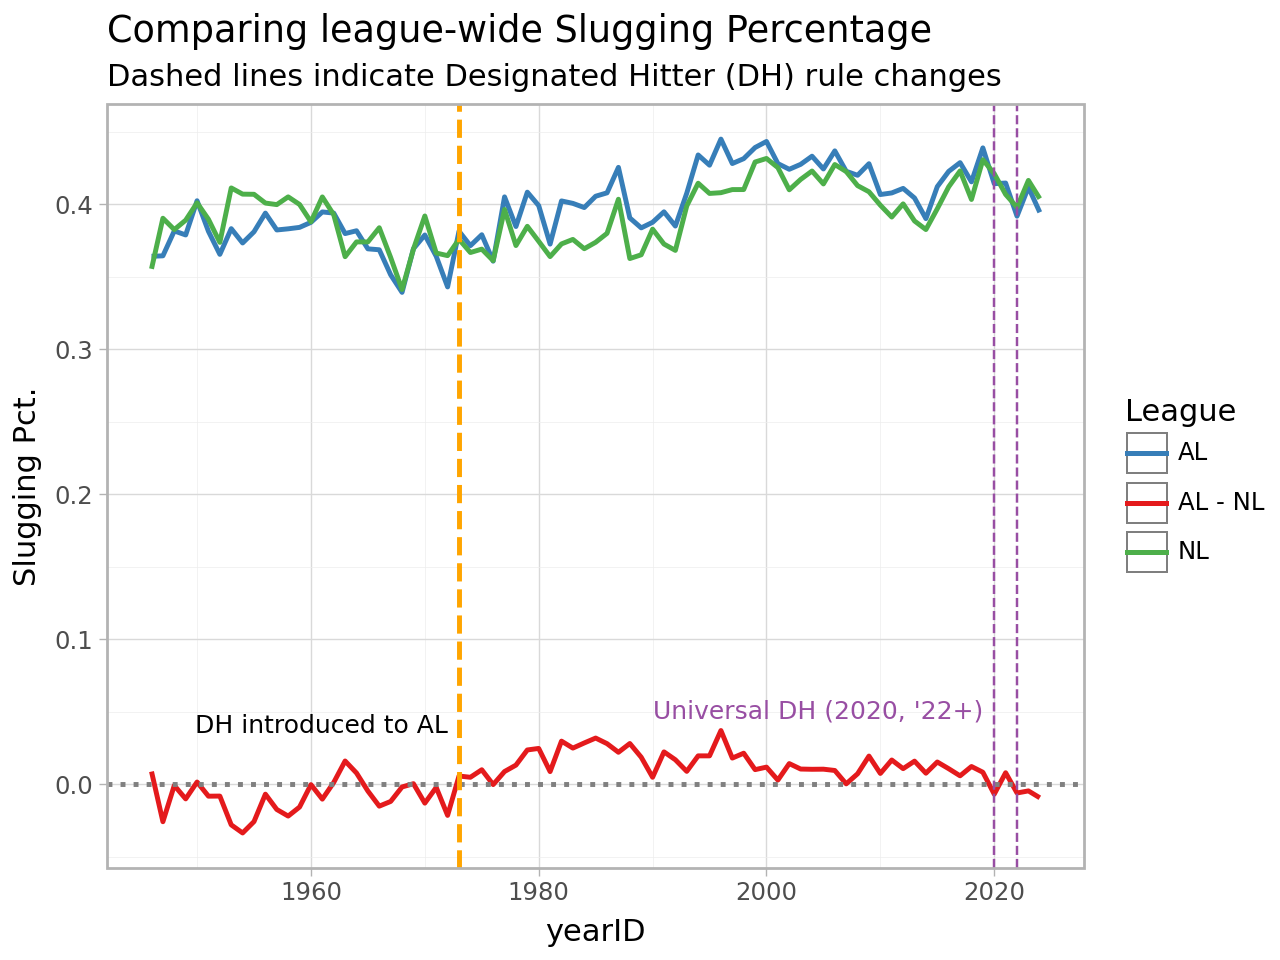

In [28]:
# Create Slugging Plot
slg_plot = (
    ggplot(slg_plot_df, aes(x="yearID", y="SLG", color="League"))
    + geom_line(size=1)
    + geom_hline(yintercept=0, linetype="dotted", color="gray", size=1)
    + geom_vline(xintercept=1973, linetype="dashed", color="orange", size=1)
    + geom_vline(xintercept=2020, linetype="dashed", color="#984ea3")
    + geom_vline(xintercept=2022, linetype="dashed", color="#984ea3")
    + annotate("text", x=1972, y=0.04, label="DH introduced to AL", ha="right", size=9)
    + annotate("text", x=2019, y=0.05, label="Universal DH (2020, '22+)", ha="right", size=9, color="#984ea3")
    + labs(
        title="Comparing league-wide Slugging Percentage",
        subtitle="Dashed lines indicate Designated Hitter (DH) rule changes",
        x="yearID", y="Slugging Pct.", color="League"
    )
    + scale_color_manual(values=league_colors)
    + theme_light()
)

slg_plot

In [29]:
# Task 4: Save both plots to PNG files
img_dir = Path("img")
img_dir.mkdir(exist_ok=True)
era_plot_path = img_dir / "league_era_comparison.png"
slg_plot_path = img_dir / "league_slugging_comparison.png"

ggsave(era_plot, filename=era_plot_path, width=10, height=6, dpi=300)
ggsave(slg_plot, filename=slg_plot_path, width=10, height=6, dpi=300)

print(f"Plots saved to: \n- {era_plot_path}\n- {slg_plot_path}")

/root/anaconda3/lib/python3.12/site-packages/plotnine/ggplot.py:630: PlotnineWarning: Saving 10 x 6 in image.
/root/anaconda3/lib/python3.12/site-packages/plotnine/ggplot.py:631: PlotnineWarning: Filename: img/league_era_comparison.png
/root/anaconda3/lib/python3.12/site-packages/plotnine/ggplot.py:630: PlotnineWarning: Saving 10 x 6 in image.
/root/anaconda3/lib/python3.12/site-packages/plotnine/ggplot.py:631: PlotnineWarning: Filename: img/league_slugging_comparison.png


Plots saved to: 
- img/league_era_comparison.png
- img/league_slugging_comparison.png


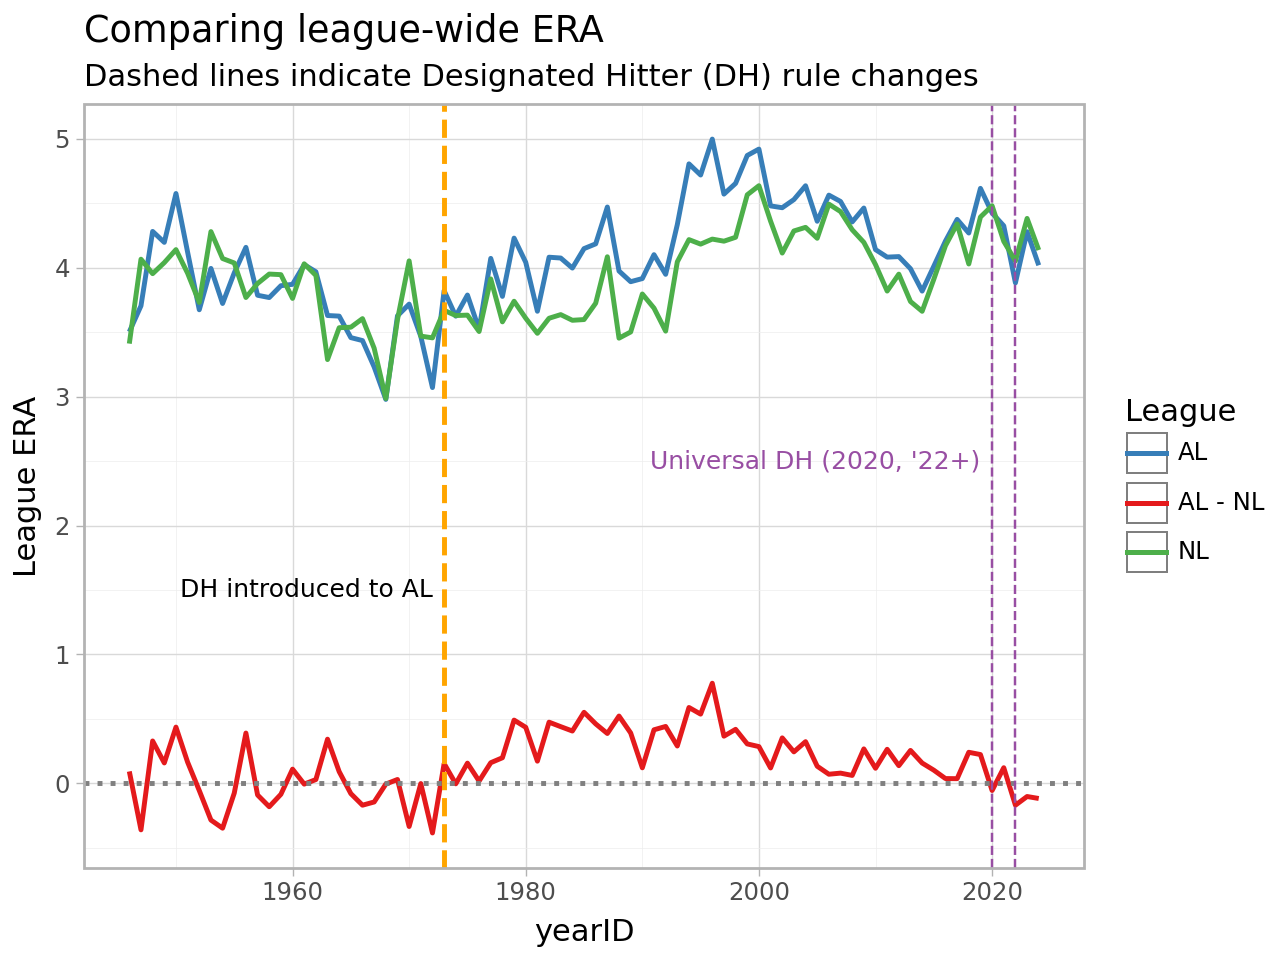


Plot saved to img/league_era_comparison.png


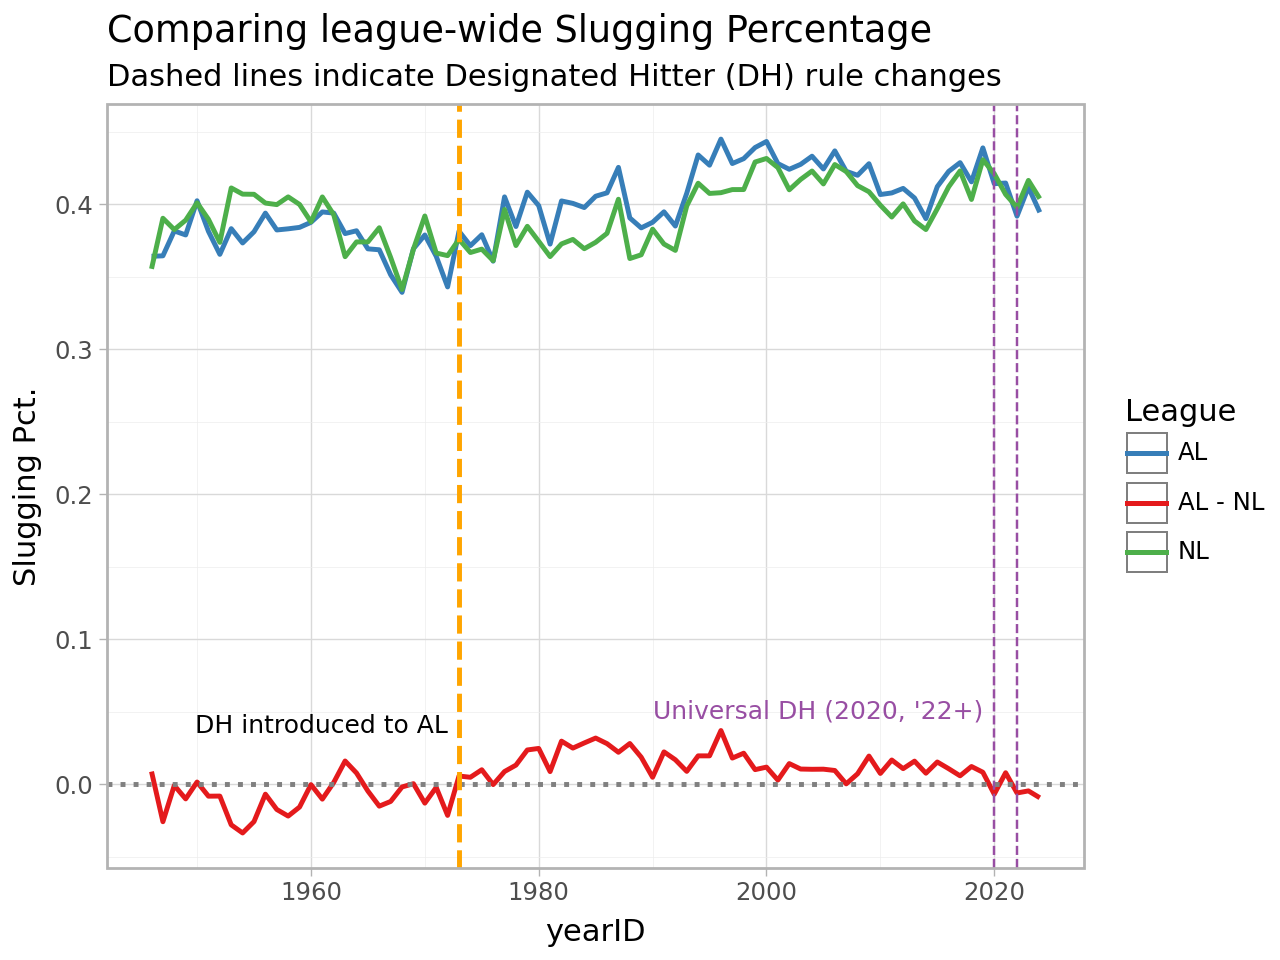


Plot saved to img/league_slugging_comparison.png


In [33]:
# 5. Display the Plot
era_plot.show()
print("\nPlot saved to img/league_era_comparison.png")
slg_plot.show()
print("\nPlot saved to img/league_slugging_comparison.png")